In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from src.getdata_utils import load_data, split_data



In [3]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [4]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)

Stacked Ensemble — Test ROC-AUC: 0.807
Base XGB — Test ROC-AUC: 0.796
Base RF — Test ROC-AUC: 0.796
Base LR — Test ROC-AUC: 0.772

Best Val F1 threshold: 0.167 | F1=0.492, Precision=0.454, Recall=0.538

VALIDATION @ threshold=0.167
Confusion matrix:
 [[5840  548]
 [ 391  455]]
Precision: 0.454  Recall: 0.538  F1: 0.492  ROC-AUC: 0.805

TEST @ threshold=0.167
Confusion matrix:
 [[7398  587]
 [ 521  537]]
Precision: 0.478  Recall: 0.508  F1: 0.492  ROC-AUC: 0.807

Permutation importance (ensemble meta-features) — Validation:
     feature  importance_mean  importance_std
0  proba_XGB         0.013450        0.000911
1   proba_RF         0.007009        0.000446
2   proba_LR         0.

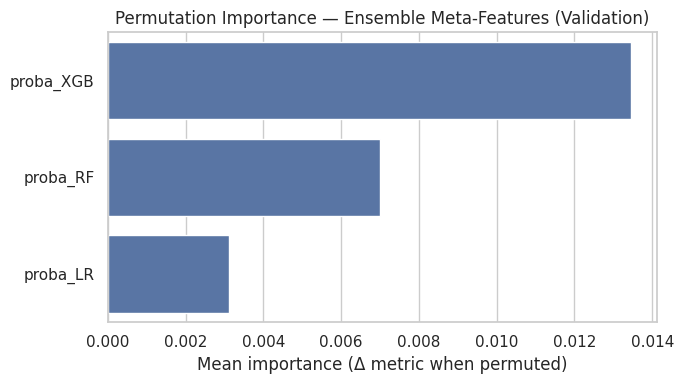


SHAP — Ensemble meta-learner (Validation meta-features)


/tmp/ipykernel_156919/3842528689.py:248: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)


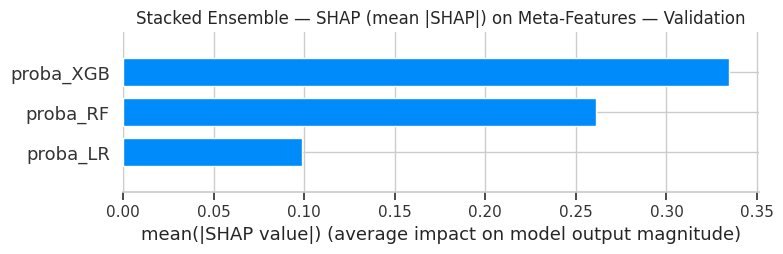

/tmp/ipykernel_156919/3842528689.py:252: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)


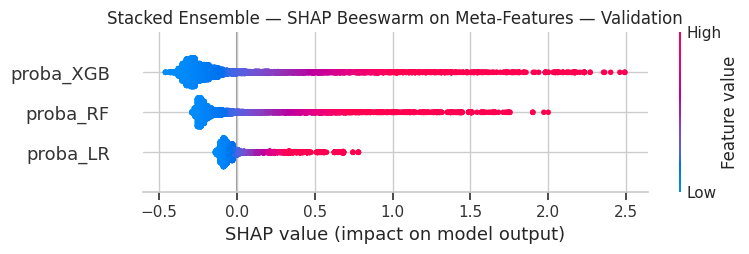


Permutation importance — XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134628        0.003284
8                  day         0.070597        0.000964
7              contact         0.055778        0.002704
12            poutcome         0.020528        0.001178
5              housing         0.011073        0.002376
11            previous         0.007575        0.001043
0                  age         0.007534        0.002091
10            campaign         0.004451        0.001333
13  was_prev_contacted         0.001175        0.000285
4              default         0.000097        0.000322
2              marital        -0.000014        0.001026
6                 loan        -0.000912        0.001207
1                  job        -0.001714        0.001189
3            education        -0.002447        0.000896
14        balance_slog        -0.003138        0.001875


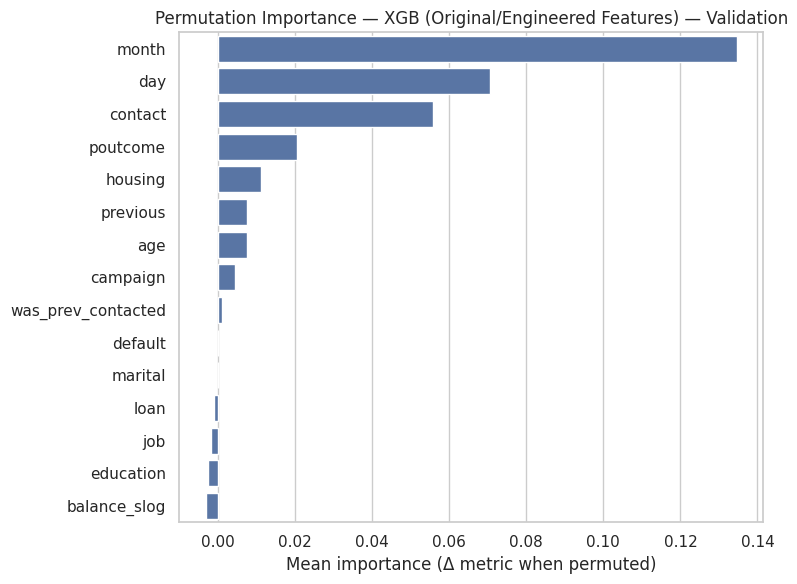


SHAP — XGB base model (Validation features)


/tmp/ipykernel_156919/3842528689.py:304: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, show=False)


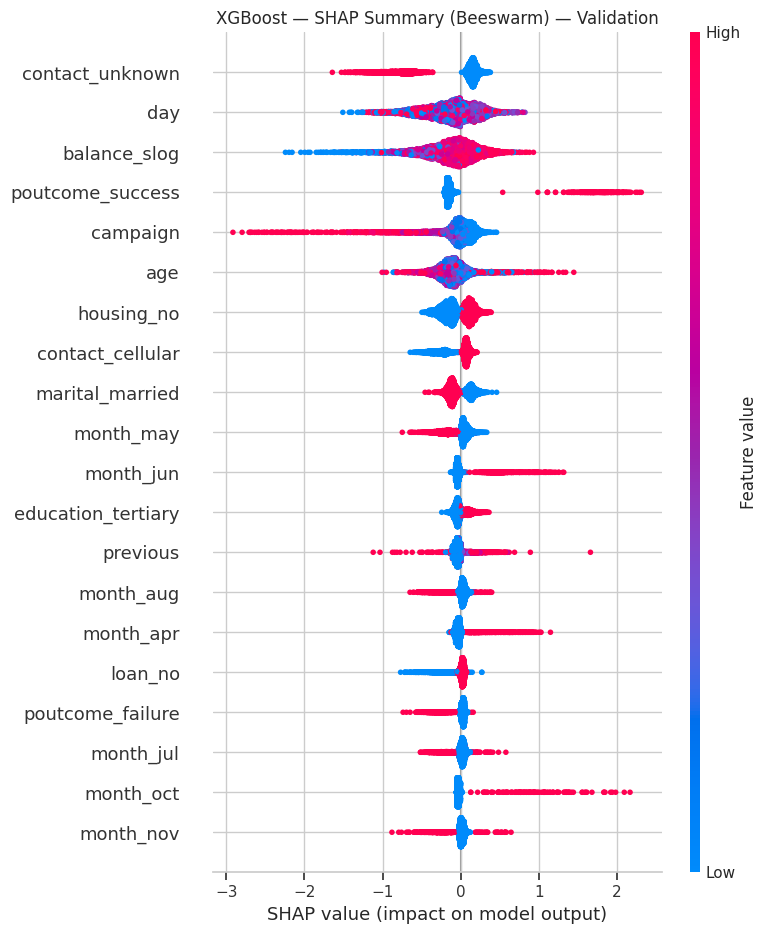

/tmp/ipykernel_156919/3842528689.py:309: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)


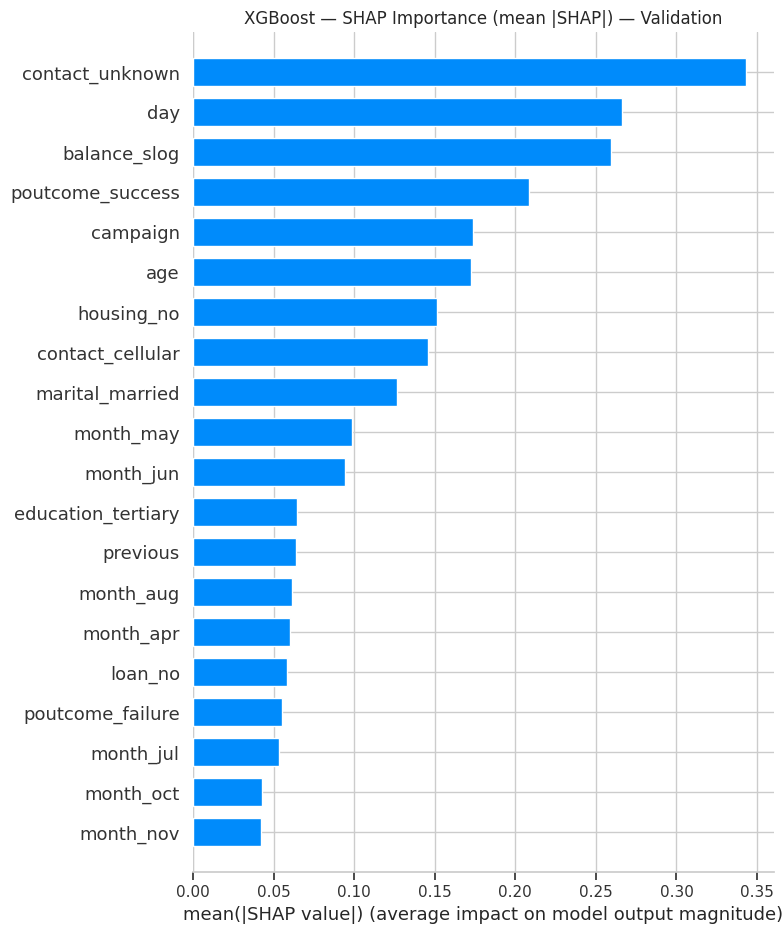


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.603671
3              contact       0.512263
12            poutcome       0.274443
4                  day       0.266141
1         balance_slog       0.259135
8                  job       0.196895
7              housing       0.175587
2             campaign       0.173791
0                  age       0.172598
10             marital       0.172358
6            education       0.124366
13            previous       0.063676
9                 loan       0.062004
14  was_prev_contacted       0.007567
5              default       0.005396


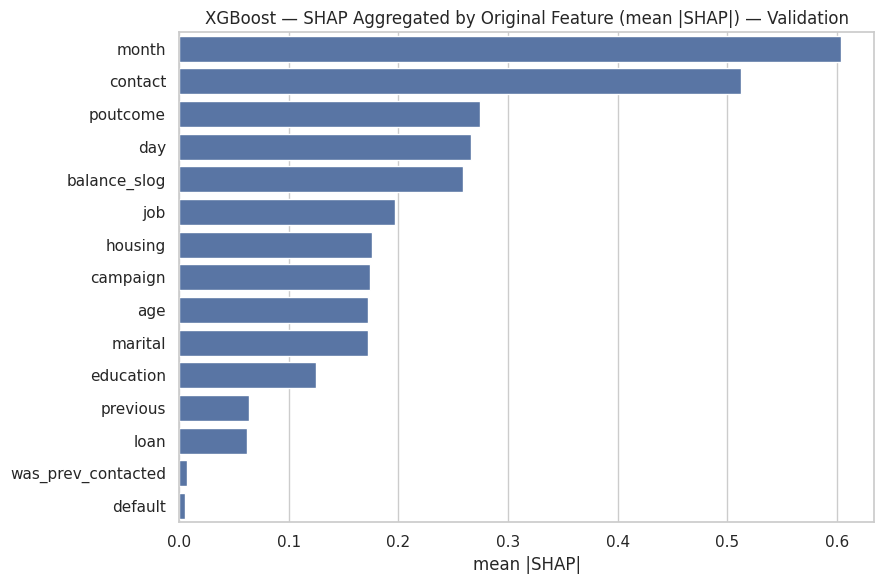

In [5]:
# ==========================================
# 0) Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing and Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) Base model builders (uncalibrated)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        )),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

def make_lr():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            C=1.0,
            n_jobs=-1,
            random_state=42
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf, "lr": make_lr}

# ==========================================
# 5) Stacking (OOF meta-features) with calibrated bases (isotonic)
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(
            estimator=base_pipe,
            method="isotonic",
            cv=3
        )
        calib.fit(X_tr, y_tr)

        proba_va = calib.predict_proba(X_va)[:, 1]
        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = proba_va

        proba_test = calib.predict_proba(X_test)[:, 1]
        test_meta_parts[name] += proba_test / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

# Meta-learner (keep LR as your chosen stacker)
meta_clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=1.0, n_jobs=-1, random_state=42)
meta_clf.fit(oof_meta.values, y_trainval.values)

# Build TEST meta matrix from averaged base predictions
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# Ensemble performance on TEST
test_meta_proba = meta_clf.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble — Test ROC-AUC: {ensemble_auc:.3f}")

# Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 6) Threshold tuning on VALIDATION (maximize F1 by default)
# ==========================================
val_meta_feats, meta_feature_names = [], []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    proba_val = calib_train.predict_proba(X_val)[:, 1]
    val_meta_feats.append(proba_val)
    meta_feature_names.append(f"proba_{name.upper()}")

val_meta = np.column_stack(val_meta_feats)
val_meta_proba = meta_clf.predict_proba(val_meta)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, val_meta_proba)
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

print_metrics("VALIDATION", y_val, val_meta_proba, best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 7) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_clf, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title("Permutation Importance — Ensemble Meta-Features (Validation)")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 8) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    explainer_meta = shap.LinearExplainer(meta_clf, val_meta)
    shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title("Stacked Ensemble — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title("Stacked Ensemble — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("LinearExplainer fallback -> KernelExplainer due to:", e)
    background = val_meta[:200]
    explainer_meta = shap.KernelExplainer(meta_clf.predict_proba, background)
    shap_vals_meta = explainer_meta.shap_values(val_meta, nsamples=200)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title("Stacked Ensemble — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

# ==========================================
# 9) PERMUTATION IMPORTANCE — XGB (original features) on VALIDATION
#    (model-agnostic, importance per original/engineered column)
# ==========================================
print("\nPermutation importance — XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 10) SHAP — XGB base model on Validation (feature-level)
# ==========================================
print("\nSHAP — XGB base model (Validation features)")
# Transform X_val and get transformed feature names
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

# TreeExplainer on XGB
explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_trans)

# Beeswarm (direction + impact)
shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

# Bar (global importance)
shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

# Aggregate SHAP back to ORIGINAL columns (sum |SHAP| across one-hot levels)
mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()

In [6]:
# ==========================================
# Pickle the final stacked model (calibrated bases + LR meta)
# ==========================================
import joblib
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# 1) Fit calibrated base pipelines on full Train+Val
calibrated_bases = {}
for name, builder in base_builders.items():
    base_pipe = builder()  # pipeline: preprocessor -> clf
    calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib.fit(X_trainval, y_trainval)
    calibrated_bases[name] = calib

# 2) Build Train+Val meta-features for the stacker
meta_cols = [f"proba_{k.upper()}" for k in calibrated_bases.keys()]
trainval_meta = np.column_stack([
    calibrated_bases[name].predict_proba(X_trainval)[:, 1] for name in calibrated_bases.keys()
])

# 3) Fit meta-learner (same as in your evaluation: Logistic Regression)
meta_clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=1.0, n_jobs=-1, random_state=42)
meta_clf.fit(trainval_meta, y_trainval)

# 4) Wrap into a deployable class
class StackedEnsemble:
    """
    Deployable scorer for the term-deposit project.
    Expects a raw dataframe X with the same columns used in training
    (no manual scaling or one-hot needed; bases contain the preprocessor).
    """
    def __init__(self, calibrated_bases: dict, meta_clf, num_features, cat_features, meta_cols, threshold: float = 0.5):
        self.calibrated_bases = calibrated_bases   # dict: name -> CalibratedClassifierCV(pipeline)
        self.meta_clf = meta_clf                   # LogisticRegression (stacker)
        self.num_features = list(num_features)
        self.cat_features = list(cat_features)
        self.meta_cols = list(meta_cols)
        self.threshold = float(threshold)

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return final ensemble probabilities; [:,1] is P(yes)."""
        meta = np.column_stack([
            self.calibrated_bases[name].predict_proba(X)[:, 1]
            for name in self.calibrated_bases.keys()
        ])
        p1 = self.meta_clf.predict_proba(meta)[:, 1]
        return np.column_stack([1 - p1, p1])

    def predict(self, X: pd.DataFrame, threshold: float = None) -> np.ndarray:
        """Return 0/1 labels using saved threshold (or override)."""
        thr = self.threshold if threshold is None else float(threshold)
        return (self.predict_proba(X)[:, 1] >= thr).astype(int)

    def info(self) -> dict:
        return {
            "bases": list(self.calibrated_bases.keys()),
            "meta": type(self.meta_clf).__name__,
            "num_features": self.num_features,
            "cat_features": self.cat_features,
            "meta_cols": self.meta_cols,
            "threshold": self.threshold,
        }

# 5) Create the artifact with your validation-tuned threshold
artifact = StackedEnsemble(
    calibrated_bases=calibrated_bases,
    meta_clf=meta_clf,
    num_features=num_features,
    cat_features=cat_features,
    meta_cols=meta_cols,
    threshold=best_thr  # from your threshold tuning section
)

# 6) Save with joblib (recommended for sklearn objects)
joblib.dump(artifact, "term_deposit_ensemble.pkl", compress=3)
print("Saved: term_deposit_ensemble.pkl")

# (Optional) Save a tiny bundle with metadata
bundle = {
    "artifact": artifact,
    "metadata": {
        "model_name": "term_deposit_stacked_v1",
        "bases": list(calibrated_bases.keys()),
        "meta": "LogisticRegression",
        "threshold": float(best_thr),
        "notes": "Calibrated bases (isotonic, cv=3). Stacker=LR. Trained on Train+Val. Same schema as training, 'duration' excluded.",
    }
}
joblib.dump(bundle, "term_deposit_ensemble_bundle.pkl", compress=3)
print("Saved: term_deposit_ensemble_bundle.pkl")


Saved: term_deposit_ensemble.pkl
Saved: term_deposit_ensemble_bundle.pkl


If the team just needs a model to score new customers → share term_deposit_ensemble.pkl.

If the team also wants context (threshold, features, notes) → share the bundle.

How the team and can load:

import pandas as pd
import joblib

# Load the artifact
model = joblib.load("term_deposit_ensemble.pkl")

# Load new raw data (same columns & types used in training; do not pre-one-hot/scale)
new_df = pd.read_csv("new_contacts.csv")

# Probabilities ([:,1] is P(yes))
proba = model.predict_proba(new_df)[:, 1]

# 0/1 labels using baked-in threshold (or override with predict(..., threshold=0.22))
labels = model.predict(new_df)

scored = new_df.copy()
scored["prob_yes"] = proba
scored["call_flag"] = labels
scored.to_csv("scored_contacts.csv", index=False)
print("Scored file written: scored_contacts.csv")

Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)

Running RandomizedSearchCV for XGB base...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGB params: {'clf__colsample_bytree': 0.7304414628598096, 'clf__gamma': 1.3270035382161116, 'clf__learning_rate': 0.010455542546159682, 'clf__max_depth': 6, 'clf__min_child_weight': 6, 'clf__n_estimators': 737, 'clf__reg_lambda': 1.4712275071724532, 'clf__subsample': 0.8345272428958741}
Best CV AUC (XGB search): 0.794
Base learners included: ['xgb', 'rf', 'lr']
Meta LR VAL AUC:  0.807
Meta XGB VAL AUC: 0.808

Stacked Ensemble (XGB meta) — Test ROC-AUC: 0.807
Base XGB — Test ROC-AUC: 0.806
Base RF — Test ROC-AUC: 0.794
Base LR — Test ROC-AUC: 0.772

Best Val F1 threshold: 0.2

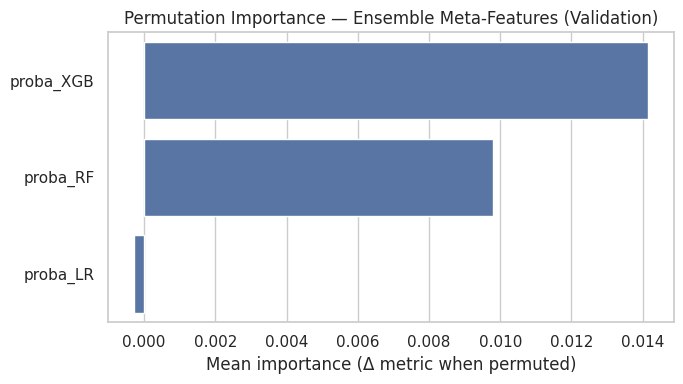


SHAP — Ensemble meta-learner (Validation meta-features)


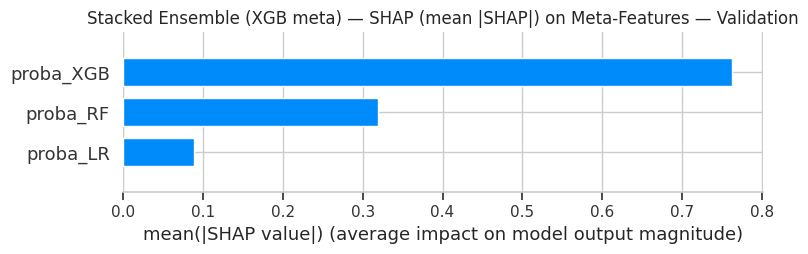

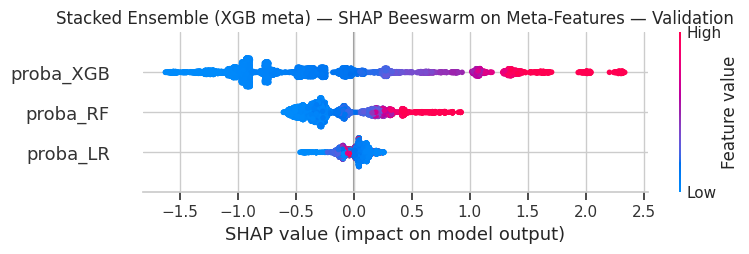


Permutation importance — Tuned XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134739        0.003363
8                  day         0.065579        0.002128
7              contact         0.053912        0.001423
12            poutcome         0.027468        0.000868
5              housing         0.016132        0.001879
11            previous         0.011805        0.001135
0                  age         0.009359        0.001385
10            campaign         0.004424        0.001484
13  was_prev_contacted         0.002502        0.000477
6                 loan         0.000194        0.001160
4              default         0.000041        0.000303
1                  job        -0.000954        0.000888
14        balance_slog        -0.002032        0.001703
3            education        -0.002350        0.001114
2              marital        -0.003732        0.001058


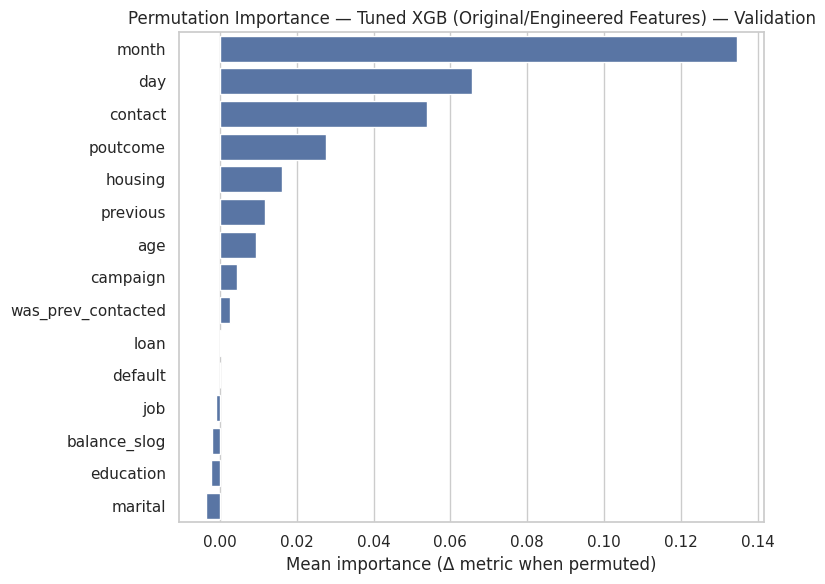


SHAP — Tuned XGB base model (Validation features)


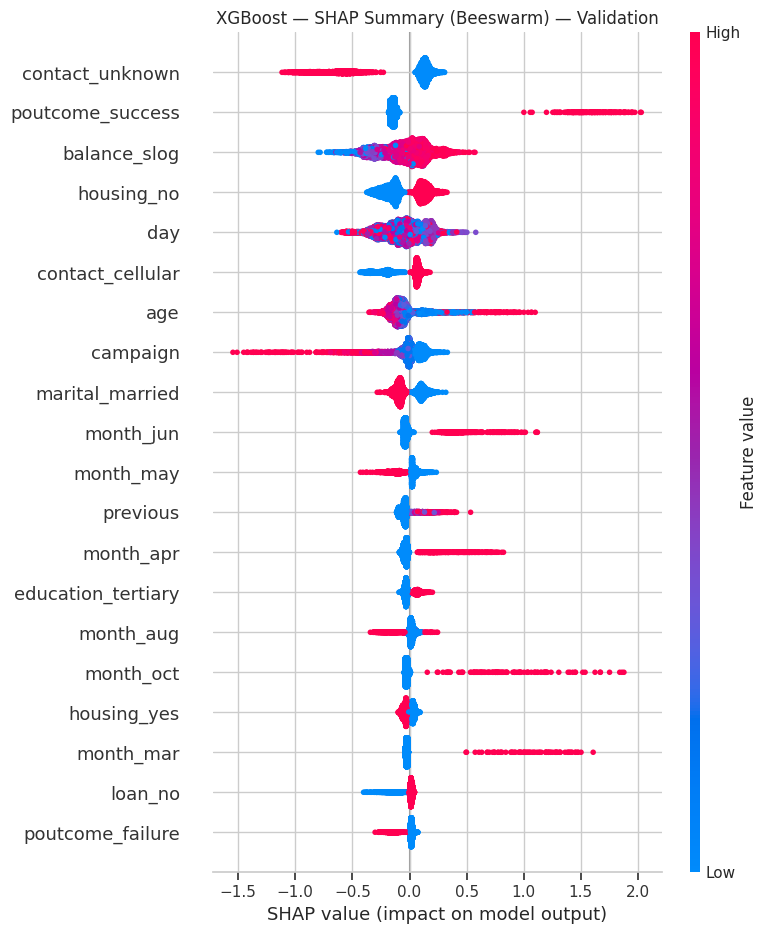

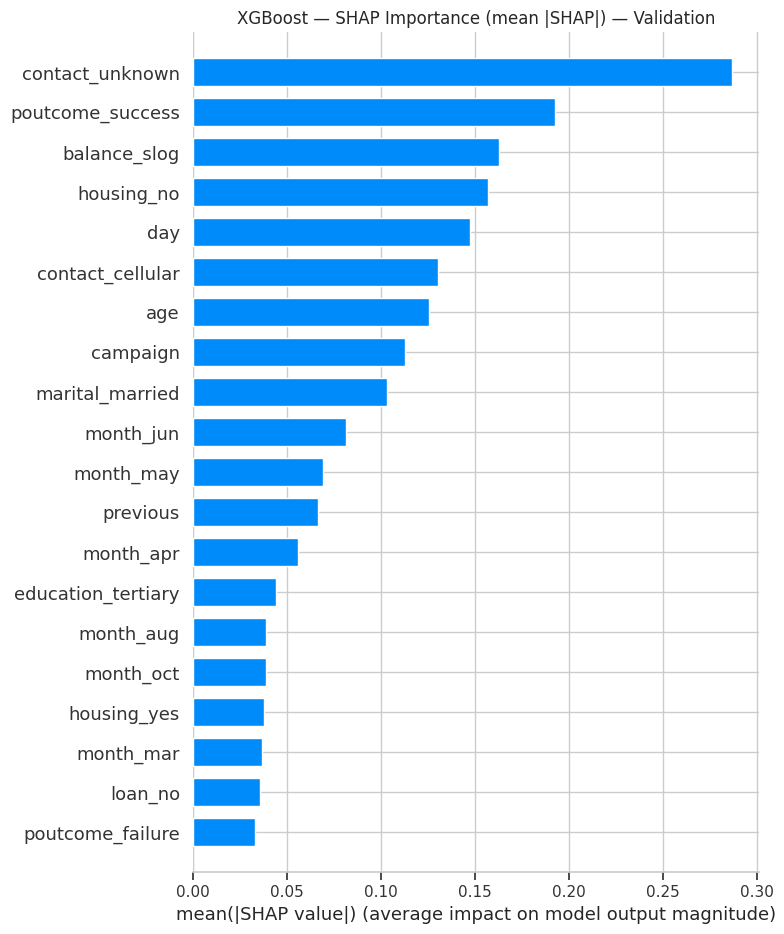


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.455573
3              contact       0.422335
12            poutcome       0.237281
7              housing       0.194962
1         balance_slog       0.162593
4                  day       0.147368
10             marital       0.141393
0                  age       0.125496
2             campaign       0.112891
6            education       0.069950
13            previous       0.066292
8                  job       0.059463
9                 loan       0.050932
14  was_prev_contacted       0.010289
5              default       0.000959


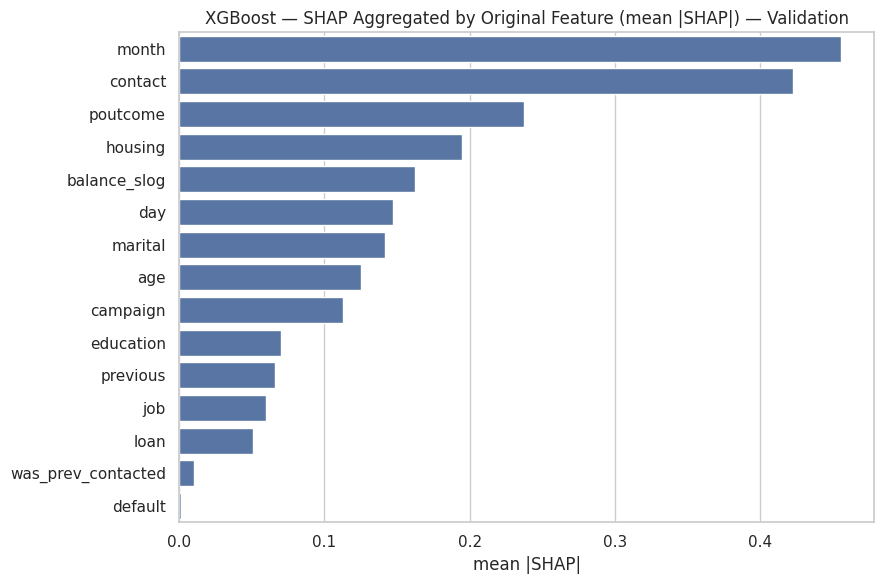

In [7]:
# ==========================================
# 0) Imports & toggles
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets

# ---- Optional LightGBM base model
USE_LGBM = True
try:
    from lightgbm import LGBMClassifier
except Exception:
    USE_LGBM = False

# ---- Try tiny XGB meta-learner & pick best vs LR
USE_XGB_META = True

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing & Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) XGB hyperparameter search (RandomizedSearchCV on TRAIN)
#    -> Produces tuned params for the XGB base builder
# ==========================================
xgb_search_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        scale_pos_weight=scale_pos_weight
    )),
])

# Focused, generalization-friendly ranges
param_distributions = {
    "clf__n_estimators": randint(400, 1600),
    "clf__learning_rate": uniform(0.01, 0.09),  # 0.01–0.10
    "clf__max_depth": randint(3, 7),            # 3–6
    "clf__subsample": uniform(0.7, 0.3),        # 0.7–1.0
    "clf__colsample_bytree": uniform(0.7, 0.3), # 0.7–1.0
    "clf__min_child_weight": randint(1, 8),
    "clf__gamma": uniform(0.0, 2.0),
    # Optional L2 reg
    "clf__reg_lambda": uniform(0.5, 2.0),
}

rs_cv = RandomizedSearchCV(
    xgb_search_pipe,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("\nRunning RandomizedSearchCV for XGB base...")
rs_cv.fit(X_train, y_train)
print("Best XGB params:", rs_cv.best_params_)
print("Best CV AUC (XGB search):", round(rs_cv.best_score_, 3))

best_xgb = rs_cv.best_estimator_.named_steps["clf"]
best_xgb_params = rs_cv.best_params_.copy()
# strip pipeline prefixes for clarity if needed later
best_xgb_clean = XGBClassifier(
    **{k.replace("clf__", ""): v for k, v in best_xgb_params.items()},
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

# ==========================================
# 5) Base model builders (using tuned XGB)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", best_xgb_clean),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=700,   # slight bump for stability
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

def make_lr():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=3000,
            C=1.0,
            n_jobs=-1,
            random_state=42
        )),
    ])

def make_lgbm():
    # Only used if USE_LGBM and lightgbm is available
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", LGBMClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=-1,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            objective="binary",
            # class_weight approx (alternative to scale_pos_weight)
            # class_weight can be dict or 'balanced'; we'll leave default
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf, "lr": make_lr}
if USE_LGBM:
    base_builders["lgbm"] = make_lgbm

print("Base learners included:", list(base_builders.keys()))

# ==========================================
# 6) Stacking (OOF meta-features) with calibrated bases (isotonic)
#    + compare LR meta vs tiny XGB meta; keep the better one by VAL AUC
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF meta for Train+Val
oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

# Averaged base predictions on TEST
test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
        calib.fit(X_tr, y_tr)

        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = calib.predict_proba(X_va)[:, 1]
        test_meta_parts[name] += calib.predict_proba(X_test)[:, 1] / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

meta_feature_names = [f"proba_{k.upper()}" for k in base_builders.keys()]
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# ---- Option A: Logistic Regression meta
meta_lr = LogisticRegression(solver="lbfgs", max_iter=3000, C=1.0, n_jobs=-1, random_state=42)
meta_lr.fit(oof_meta.values, y_trainval.values)

# Build validation meta-features (fit bases on Train only)
val_meta_feats = []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    val_meta_feats.append(calib_train.predict_proba(X_val)[:, 1])
val_meta = np.column_stack(val_meta_feats)

val_auc_lr = roc_auc_score(y_val, meta_lr.predict_proba(val_meta)[:, 1])

# ---- Option B: tiny XGB meta (if enabled)
use_meta = "lr"
meta_final = meta_lr
if USE_XGB_META:
    meta_xgb = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05,
        subsample=0.9, colsample_bytree=1.0,
        eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
    )
    meta_xgb.fit(oof_meta.values, y_trainval.values)
    val_auc_xgb = roc_auc_score(y_val, meta_xgb.predict_proba(val_meta)[:, 1])

    print(f"Meta LR VAL AUC:  {val_auc_lr:.3f}")
    print(f"Meta XGB VAL AUC: {val_auc_xgb:.3f}")

    if val_auc_xgb >= val_auc_lr:
        use_meta = "xgb"
        meta_final = meta_xgb

# ---- Evaluate on TEST
test_meta_proba = meta_final.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble ({use_meta.upper()} meta) — Test ROC-AUC: {ensemble_auc:.3f}")

# ---- Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 7) Threshold tuning on VALIDATION (maximize F1 by default)
# ==========================================
prec, rec, thr = precision_recall_curve(y_val, meta_final.predict_proba(val_meta)[:, 1])
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

# Print VAL/TEST at best_thr
print_metrics("VALIDATION", y_val, meta_final.predict_proba(val_meta)[:, 1], best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 8) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_final, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title("Permutation Importance — Ensemble Meta-Features (Validation)")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 9) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    if use_meta == "lr":
        explainer_meta = shap.LinearExplainer(meta_final, val_meta)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    else:
        explainer_meta = shap.TreeExplainer(meta_final)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Meta SHAP fallback:", e)

# ==========================================
# 10) PERMUTATION IMPORTANCE — Tuned XGB (original features) on VALIDATION
# ==========================================
print("\nPermutation importance — Tuned XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — Tuned XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 11) SHAP — Tuned XGB base on Validation (feature-level)
# ==========================================
print("\nSHAP — Tuned XGB base model (Validation features)")
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_trans)

shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals_val, X_val_trans, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)
Base learners included: ['xgb', 'rf']
Meta LR VAL AUC:  0.806
Meta XGB VAL AUC: 0.808

Stacked Ensemble (XGB meta) — Test ROC-AUC: 0.808
Base XGB — Test ROC-AUC: 0.806
Base RF — Test ROC-AUC: 0.794

Best Val F1 threshold: 0.285 | F1=0.496, Precision=0.455, Recall=0.545

VALIDATION @ threshold=0.285
Confusion matrix:
 [[5836  552]
 [ 385  461]]
Precision: 0.455  Recall: 0.545  F1: 0.496  ROC-AUC: 0.808

TEST @ threshold=0.285
Confusion matrix:
 [[7354  631]
 [ 523  535]]
Precision: 0.459  Recall: 0.506  F1: 0.481  ROC-AUC: 0.808

Permutation importance (ensemble meta-features) — Validation:
     feature  importance_mean  importance_std
0  proba_XGB         0.017183        0.001040
1 

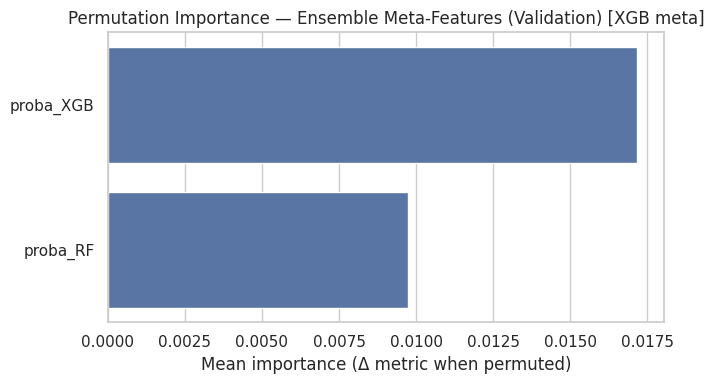


SHAP — Ensemble meta-learner (Validation meta-features)


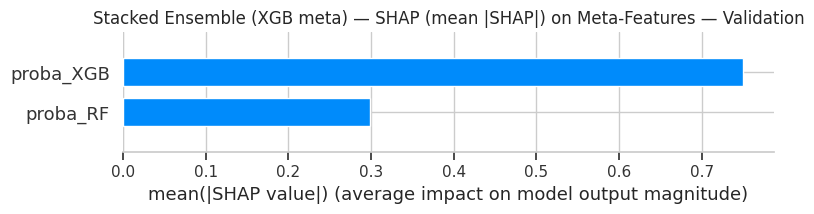

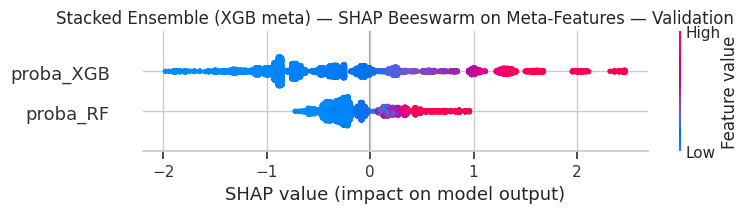


Permutation importance — Tuned XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134739        0.003363
8                  day         0.065579        0.002128
7              contact         0.053912        0.001423
12            poutcome         0.027468        0.000868
5              housing         0.016132        0.001879
11            previous         0.011805        0.001135
0                  age         0.009359        0.001385
10            campaign         0.004424        0.001484
13  was_prev_contacted         0.002502        0.000477
6                 loan         0.000194        0.001160
4              default         0.000041        0.000303
1                  job        -0.000954        0.000888
14        balance_slog        -0.002032        0.001703
3            education        -0.002350        0.001114
2              marital        -0.003732        0.001058


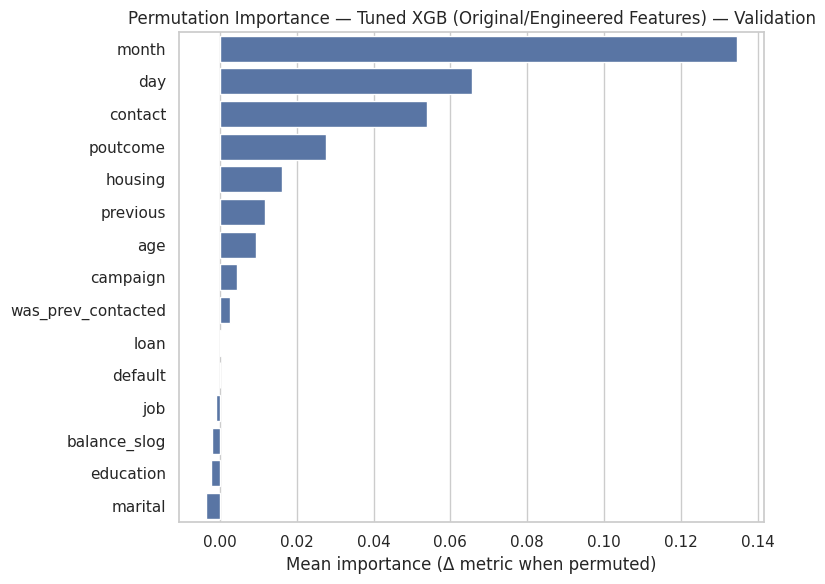


SHAP — Tuned XGB base model (Validation features)


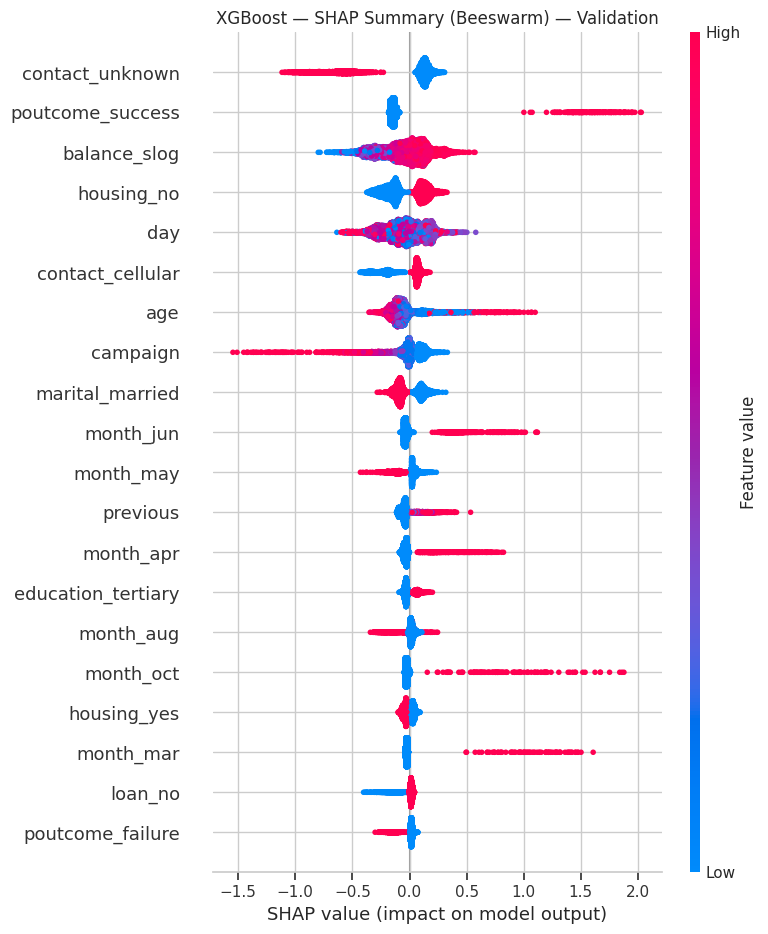

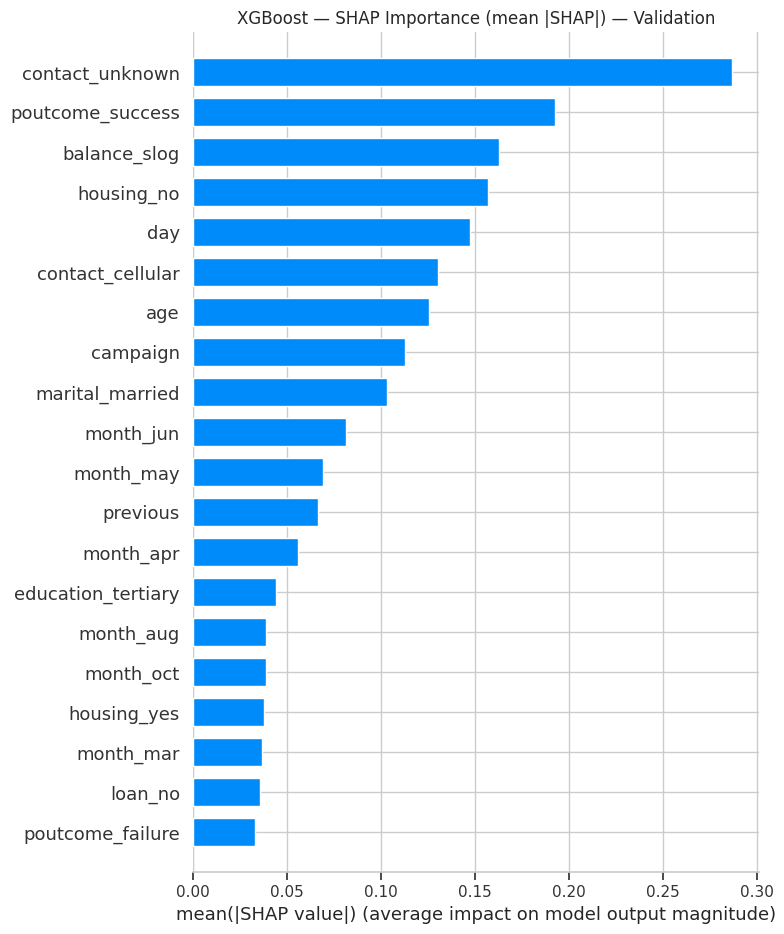


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.455573
3              contact       0.422335
12            poutcome       0.237281
7              housing       0.194962
1         balance_slog       0.162593
4                  day       0.147368
10             marital       0.141393
0                  age       0.125496
2             campaign       0.112891
6            education       0.069950
13            previous       0.066292
8                  job       0.059463
9                 loan       0.050932
14  was_prev_contacted       0.010289
5              default       0.000959


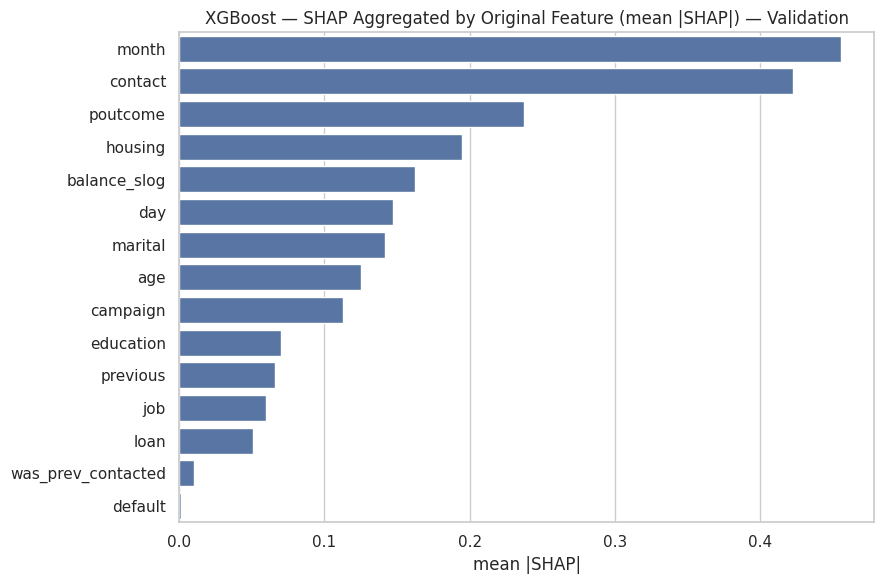

In [8]:
# ==========================================
# 0) Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets
from scipy import sparse

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing and Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage)
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)

print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) Tuned XGB params (from your RandomizedSearchCV)
# ==========================================
TUNED_XGB_PARAMS = dict(
    n_estimators=737,
    learning_rate=0.010455542546159682,
    max_depth=6,
    subsample=0.8345272428958741,
    colsample_bytree=0.7304414628598096,
    min_child_weight=6,
    gamma=1.3270035382161116,
    reg_lambda=1.4712275071724532,
)

# ==========================================
# 5) Base model builders (XGB + RF only)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
            **TUNED_XGB_PARAMS,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        )),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=700,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf}
print("Base learners included:", list(base_builders.keys()))

# ==========================================
# 6) Stacking (OOF meta-features) with calibrated bases (isotonic)
#    + compare LR meta vs tiny XGB meta; keep the better one by VAL AUC
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF meta for Train+Val
oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

# Averaged base predictions on TEST
test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
        calib.fit(X_tr, y_tr)

        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = calib.predict_proba(X_va)[:, 1]
        test_meta_parts[name] += calib.predict_proba(X_test)[:, 1] / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

meta_feature_names = [f"proba_{k.upper()}" for k in base_builders.keys()]
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# ---- Build validation meta-features (fit bases on Train only)
val_meta_feats = []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    val_meta_feats.append(calib_train.predict_proba(X_val)[:, 1])
val_meta = np.column_stack(val_meta_feats)

# ---- Option A: Logistic Regression meta
meta_lr = LogisticRegression(solver="lbfgs", max_iter=3000, C=1.0, n_jobs=-1, random_state=42)
meta_lr.fit(oof_meta.values, y_trainval.values)
val_auc_lr = roc_auc_score(y_val, meta_lr.predict_proba(val_meta)[:, 1])

# ---- Option B: tiny XGB meta
meta_xgb = XGBClassifier(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    subsample=0.9, colsample_bytree=1.0,
    eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
)
meta_xgb.fit(oof_meta.values, y_trainval.values)
val_auc_xgb = roc_auc_score(y_val, meta_xgb.predict_proba(val_meta)[:, 1])

print(f"Meta LR VAL AUC:  {val_auc_lr:.3f}")
print(f"Meta XGB VAL AUC: {val_auc_xgb:.3f}")

use_meta = "xgb" if val_auc_xgb >= val_auc_lr else "lr"
meta_final = meta_xgb if use_meta == "xgb" else meta_lr

# ---- Evaluate on TEST
test_meta_proba = meta_final.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble ({use_meta.upper()} meta) — Test ROC-AUC: {ensemble_auc:.3f}")

# ---- Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 7) Threshold tuning on VALIDATION (maximize F1 by default)
# ==========================================
prec, rec, thr = precision_recall_curve(y_val, meta_final.predict_proba(val_meta)[:, 1])
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

# Print VAL/TEST at best_thr
print_metrics("VALIDATION", y_val, meta_final.predict_proba(val_meta)[:, 1], best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 8) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_final, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title(f"Permutation Importance — Ensemble Meta-Features (Validation) [{use_meta.upper()} meta]")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 9) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    if use_meta == "lr":
        explainer_meta = shap.LinearExplainer(meta_final, val_meta)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    else:
        explainer_meta = shap.TreeExplainer(meta_final)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Meta SHAP fallback/error:", e)

# ==========================================
# 10) PERMUTATION IMPORTANCE — Tuned XGB (original features) on VALIDATION
# ==========================================
print("\nPermutation importance — Tuned XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — Tuned XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 11) SHAP — Tuned XGB base on Validation (feature-level)
# ==========================================
print("\nSHAP — Tuned XGB base model (Validation features)")
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

# convert sparse to dense for SHAP if needed
X_val_shap = X_val_trans.toarray() if sparse.issparse(X_val_trans) else X_val_trans

explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_shap)

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()


Numeric features: ['age', 'day', 'campaign', 'previous', 'was_prev_contacted', 'balance_slog']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shapes -> Train: (28934, 15), Val: (7234, 15), Test: (9043, 15)
scale_pos_weight ≈ 7.55 (neg/pos)
Base learners included: ['xgb', 'rf']
Meta LR VAL AUC:  0.806
Meta XGB VAL AUC: 0.808

Stacked Ensemble (XGB meta) — Test ROC-AUC: 0.808
Base XGB — Test ROC-AUC: 0.806
Base RF — Test ROC-AUC: 0.794

Best Val F1 threshold: 0.285 | F1=0.496, Precision=0.455, Recall=0.545

VALIDATION @ threshold=0.285
Confusion matrix:
 [[5836  552]
 [ 385  461]]
Precision: 0.455  Recall: 0.545  F1: 0.496  ROC-AUC: 0.808

TEST @ threshold=0.285
Confusion matrix:
 [[7354  631]
 [ 523  535]]
Precision: 0.459  Recall: 0.506  F1: 0.481  ROC-AUC: 0.808

Permutation importance (ensemble meta-features) — Validation:
     feature  importance_mean  importance_std
0  proba_XGB         0.017183        0.001040
1 

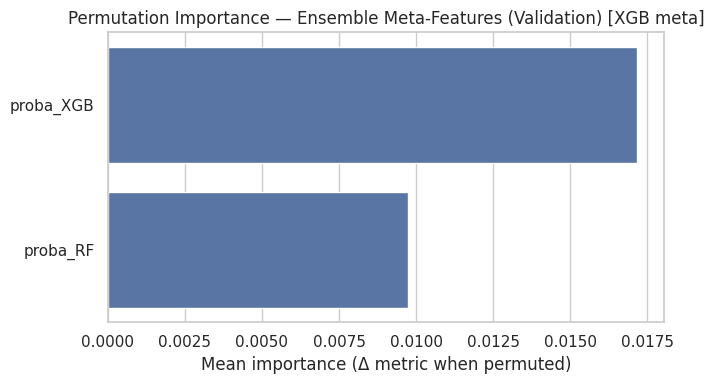


SHAP — Ensemble meta-learner (Validation meta-features)


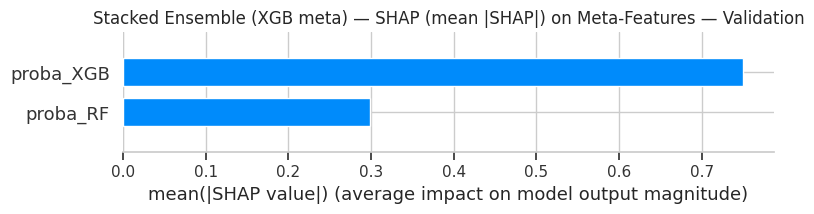

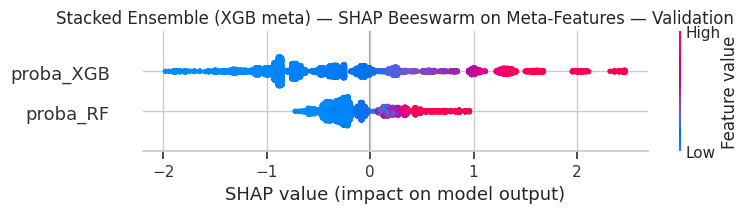


Permutation importance — Tuned XGB pipeline (original features) — Validation:
               feature  importance_mean  importance_std
9                month         0.134739        0.003363
8                  day         0.065579        0.002128
7              contact         0.053912        0.001423
12            poutcome         0.027468        0.000868
5              housing         0.016132        0.001879
11            previous         0.011805        0.001135
0                  age         0.009359        0.001385
10            campaign         0.004424        0.001484
13  was_prev_contacted         0.002502        0.000477
6                 loan         0.000194        0.001160
4              default         0.000041        0.000303
1                  job        -0.000954        0.000888
14        balance_slog        -0.002032        0.001703
3            education        -0.002350        0.001114
2              marital        -0.003732        0.001058


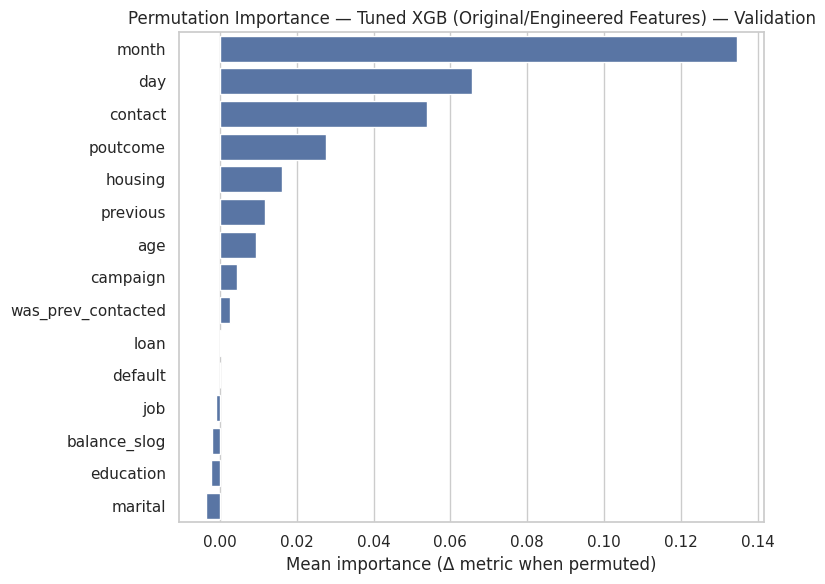


SHAP — Tuned XGB base model (Validation features)


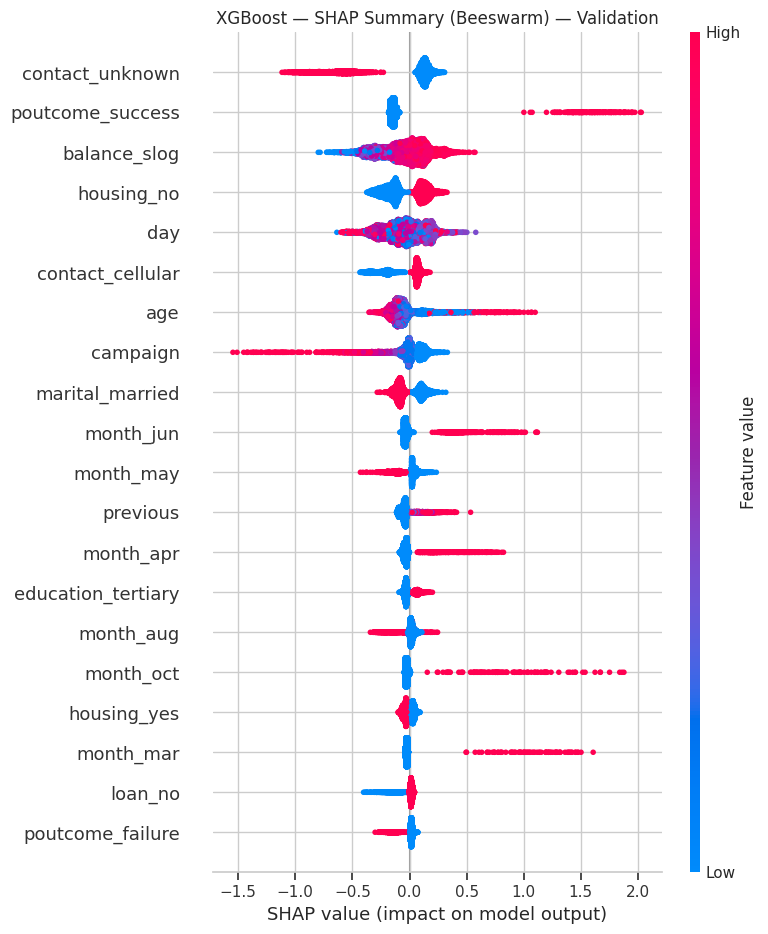

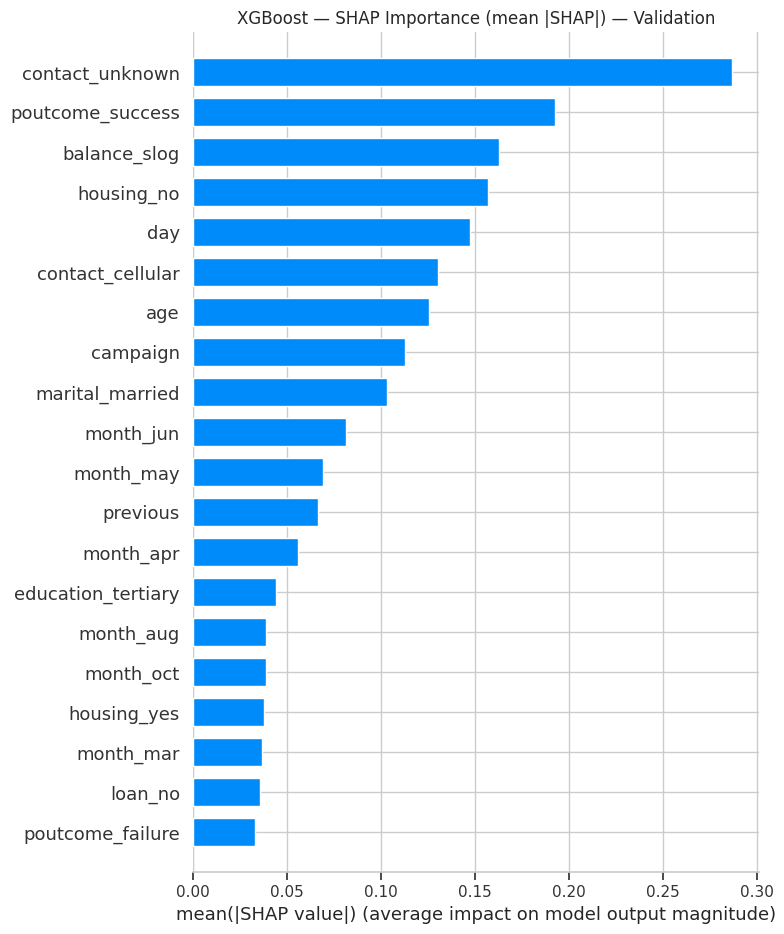


XGBoost — SHAP Importance Aggregated by Original Feature (Validation):
          feature_orig  mean_abs_shap
11               month       0.455573
3              contact       0.422335
12            poutcome       0.237281
7              housing       0.194962
1         balance_slog       0.162593
4                  day       0.147368
10             marital       0.141393
0                  age       0.125496
2             campaign       0.112891
6            education       0.069950
13            previous       0.066292
8                  job       0.059463
9                 loan       0.050932
14  was_prev_contacted       0.010289
5              default       0.000959


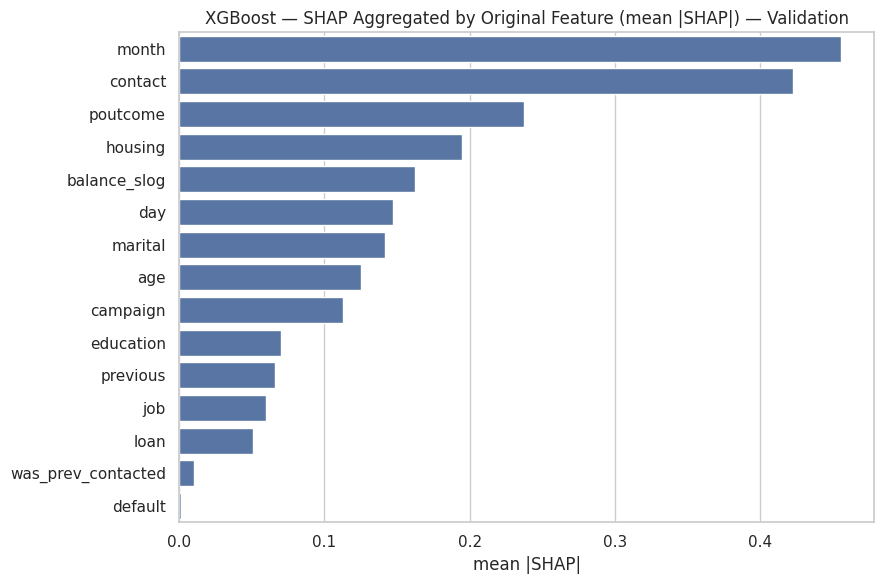

   age           job   marital  education default housing loan   contact  day  \
0   40   blue-collar   married    primary      no     yes  yes   unknown    8   
1   44    technician   married  secondary      no     yes   no   unknown   30   
2   31      services   married  secondary      no     yes   no   unknown   20   
3   36   blue-collar   married    primary      no     yes   no   unknown   23   
4   34      services    single  secondary      no     yes   no  cellular    4   
5   41    management    single  secondary      no      no   no  cellular   31   
6   43  entrepreneur   married   tertiary      no      no   no   unknown    3   
7   64       retired  divorced    primary      no      no   no  cellular   23   
8   35        admin.  divorced  secondary      no      no   no  cellular   28   
9   44      services  divorced   tertiary      no      no  yes  cellular   19   

  month  campaign  previous poutcome  was_prev_contacted  balance_slog  \
0   may         2         0  unkno

In [9]:
# ==========================================
# 0) Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_fscore_support,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import shap  # pip install shap ipywidgets
from scipy import sparse

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ==========================================
# 1) Preprocessing and Feature Engineering
# ==========================================
df2 = df.copy()

# Remove duration (leakage w.r.t. "y")
if "duration" in df2.columns:
    df2 = df2.drop(columns=["duration"])

# Create was_prev_contacted from pdays; drop pdays
if "pdays" in df2.columns:
    df2["was_prev_contacted"] = (df2["pdays"] != -1).astype(int)
    df2 = df2.drop(columns=["pdays"])

# Signed log of balance; drop raw balance
if "balance" in df2.columns:
    df2["balance_slog"] = np.sign(df2["balance"]) * np.log1p(np.abs(df2["balance"]))
    df2 = df2.drop(columns=["balance"])

# Encode target
df2["y_binary"] = df2["y"].map({"no": 0, "yes": 1}).astype(int)

X = df2.drop(columns=["y", "y_binary"])
y = df2["y_binary"]

# Identify numeric vs categorical
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

# ==========================================
# 2) Train / Val / Test split
# ==========================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42
)
print(f"Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# class imbalance ratio for XGB
neg, pos = np.bincount(y_trainval)
scale_pos_weight = neg / pos
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f} (neg/pos)")

# ==========================================
# 3) Preprocessor
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop",
)

# ==========================================
# 4) Tuned XGB params (from prior search)
# ==========================================
TUNED_XGB_PARAMS = dict(
    n_estimators=737,
    learning_rate=0.010455542546159682,
    max_depth=6,
    subsample=0.8345272428958741,
    colsample_bytree=0.7304414628598096,
    min_child_weight=6,
    gamma=1.3270035382161116,
    reg_lambda=1.4712275071724532,
)

# ==========================================
# 5) Base model builders (XGB + RF only)
# ==========================================
def make_xgb():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
            **TUNED_XGB_PARAMS,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight
        )),
    ])

def make_rf():
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=700,
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )),
    ])

base_builders = {"xgb": make_xgb, "rf": make_rf}
print("Base learners included:", list(base_builders.keys()))

# ==========================================
# 6) Stacking (OOF meta-features) with calibrated bases (isotonic)
#    + compare LR meta vs tiny XGB meta; keep the better by VAL AUC
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF meta for Train+Val
oof_meta = pd.DataFrame(index=y_trainval.index, columns=base_builders.keys(), dtype=float)
oof_meta[:] = np.nan

# Averaged base predictions on TEST
test_meta_parts = {name: np.zeros(len(X_test), dtype=float) for name in base_builders.keys()}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    X_tr, X_va = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    y_tr, y_va = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    for name, builder in base_builders.items():
        base_pipe = builder()
        calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
        calib.fit(X_tr, y_tr)

        oof_meta.loc[y_trainval.iloc[va_idx].index, name] = calib.predict_proba(X_va)[:, 1]
        test_meta_parts[name] += calib.predict_proba(X_test)[:, 1] / skf.n_splits

assert not oof_meta.isna().any().any(), "OOF meta-features contain NaNs."

meta_feature_names = [f"proba_{k.upper()}" for k in base_builders.keys()]
test_meta = np.column_stack([test_meta_parts[name] for name in base_builders.keys()])

# Build validation meta-features (fit bases on Train only)
val_meta_feats = []
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_train = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_train.fit(X_train, y_train)
    val_meta_feats.append(calib_train.predict_proba(X_val)[:, 1])
val_meta = np.column_stack(val_meta_feats)

# Option A: Logistic Regression meta
meta_lr = LogisticRegression(solver="lbfgs", max_iter=3000, C=1.0, n_jobs=-1, random_state=42)
meta_lr.fit(oof_meta.values, y_trainval.values)
val_auc_lr = roc_auc_score(y_val, meta_lr.predict_proba(val_meta)[:, 1])

# Option B: tiny XGB meta
meta_xgb = XGBClassifier(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    subsample=0.9, colsample_bytree=1.0,
    eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
)
meta_xgb.fit(oof_meta.values, y_trainval.values)
val_auc_xgb = roc_auc_score(y_val, meta_xgb.predict_proba(val_meta)[:, 1])

print(f"Meta LR VAL AUC:  {val_auc_lr:.3f}")
print(f"Meta XGB VAL AUC: {val_auc_xgb:.3f}")

use_meta = "xgb" if val_auc_xgb >= val_auc_lr else "lr"
meta_final = meta_xgb if use_meta == "xgb" else meta_lr

# Evaluate on TEST
test_meta_proba = meta_final.predict_proba(test_meta)[:, 1]
ensemble_auc = roc_auc_score(y_test, test_meta_proba)
print(f"\nStacked Ensemble ({use_meta.upper()} meta) — Test ROC-AUC: {ensemble_auc:.3f}")

# Base model TEST AUCs (calibrated on full Train+Val)
for name, builder in base_builders.items():
    base_pipe = builder()
    calib_full = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib_full.fit(X_trainval, y_trainval)
    proba = calib_full.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"Base {name.upper()} — Test ROC-AUC: {auc:.3f}")

# ==========================================
# 7) Threshold tuning on VALIDATION (maximize F1)
# ==========================================
prec, rec, thr = precision_recall_curve(y_val, meta_final.predict_proba(val_meta)[:, 1])
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = np.nanargmax(f1s)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"\nBest Val F1 threshold: {best_thr:.3f} | F1={f1s[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def print_metrics(split, y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary")
    print(f"\n{split} @ threshold={thr:.3f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")

# Print VAL/TEST at best_thr
print_metrics("VALIDATION", y_val, meta_final.predict_proba(val_meta)[:, 1], best_thr)
print_metrics("TEST", y_test, test_meta_proba, best_thr)

# ==========================================
# 8) PERMUTATION IMPORTANCE — Ensemble (meta-features) on VALIDATION
# ==========================================
print("\nPermutation importance (ensemble meta-features) — Validation:")
perm_meta = permutation_importance(
    meta_final, val_meta, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_meta_df = pd.DataFrame({
    "feature": meta_feature_names,
    "importance_mean": perm_meta.importances_mean,
    "importance_std": perm_meta.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_meta_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=perm_meta_df, x="importance_mean", y="feature")
plt.title(f"Permutation Importance — Ensemble Meta-Features (Validation) [{use_meta.upper()} meta]")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 9) SHAP — Ensemble meta-learner (on meta-features)
# ==========================================
print("\nSHAP — Ensemble meta-learner (Validation meta-features)")
try:
    if use_meta == "lr":
        explainer_meta = shap.LinearExplainer(meta_final, val_meta)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    else:
        explainer_meta = shap.TreeExplainer(meta_final)
        shap_vals_meta = explainer_meta.shap_values(val_meta)
    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, plot_type="bar", show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP (mean |SHAP|) on Meta-Features — Validation")
    plt.tight_layout(); plt.show()

    shap.summary_plot(shap_vals_meta, val_meta, feature_names=meta_feature_names, show=False)
    plt.title(f"Stacked Ensemble ({use_meta.upper()} meta) — SHAP Beeswarm on Meta-Features — Validation")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Meta SHAP fallback/error:", e)

# ==========================================
# 10) PERMUTATION IMPORTANCE — Tuned XGB (original features) on VALIDATION
# ==========================================
print("\nPermutation importance — Tuned XGB pipeline (original features) — Validation:")
xgb_pipe_uncal = make_xgb().fit(X_train, y_train)  # uncalibrated for speed/clarity
perm_xgb = permutation_importance(
    xgb_pipe_uncal, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)
print(perm_xgb_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_xgb_df.head(20), x="importance_mean", y="feature")
plt.title("Permutation Importance — Tuned XGB (Original/Engineered Features) — Validation")
plt.xlabel("Mean importance (Δ metric when permuted)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 11) SHAP — Tuned XGB base on Validation (feature-level)
# ==========================================
print("\nSHAP — Tuned XGB base model (Validation features)")
pre = xgb_pipe_uncal.named_steps["preprocess"]
X_val_trans = pre.transform(X_val)
ohe = pre.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feat_names_trans = list(num_features) + list(ohe_names)

# convert sparse to dense for SHAP if needed
X_val_shap = X_val_trans.toarray() if sparse.issparse(X_val_trans) else X_val_trans

explainer_xgb = shap.TreeExplainer(xgb_pipe_uncal.named_steps["clf"])
shap_vals_val = explainer_xgb.shap_values(X_val_shap)

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, show=False)
plt.title("XGBoost — SHAP Summary (Beeswarm) — Validation")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals_val, X_val_shap, feature_names=feat_names_trans, plot_type="bar", show=False)
plt.title("XGBoost — SHAP Importance (mean |SHAP|) — Validation")
plt.tight_layout(); plt.show()

mean_abs_shap = np.mean(np.abs(shap_vals_val), axis=0)
shap_df = pd.DataFrame({"feature_trans": feat_names_trans, "mean_abs_shap": mean_abs_shap})

def parent_name(trans_name: str) -> str:
    if trans_name in num_features:
        return trans_name
    return trans_name.split("_", 1)[0]

shap_df["feature_orig"] = shap_df["feature_trans"].apply(parent_name)
shap_agg = (shap_df.groupby("feature_orig", as_index=False)["mean_abs_shap"]
                  .sum()
                  .sort_values("mean_abs_shap", ascending=False))
print("\nXGBoost — SHAP Importance Aggregated by Original Feature (Validation):")
print(shap_agg.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=shap_agg.head(20), x="mean_abs_shap", y="feature_orig")
plt.title("XGBoost — SHAP Aggregated by Original Feature (mean |SHAP|) — Validation")
plt.xlabel("mean |SHAP|"); plt.ylabel("")
plt.tight_layout(); plt.show()

# ==========================================
# 12) Produce probability predictions & labels and save CSV
# ==========================================
from sklearn.calibration import CalibratedClassifierCV

# Refit calibrated bases on full Train+Val (never on Test)
calibrated_bases_final = {}
for name, builder in base_builders.items():  # {"xgb": make_xgb, "rf": make_rf}
    base_pipe = builder()
    calib = CalibratedClassifierCV(estimator=base_pipe, method="isotonic", cv=3)
    calib.fit(X_trainval, y_trainval)
    calibrated_bases_final[name] = calib

def ensemble_predict_proba(X_df: pd.DataFrame) -> pd.DataFrame:
    proba_xgb = calibrated_bases_final["xgb"].predict_proba(X_df)[:, 1]
    proba_rf  = calibrated_bases_final["rf"].predict_proba(X_df)[:, 1]
    meta_in   = np.column_stack([proba_xgb, proba_rf])
    proba_ens = meta_final.predict_proba(meta_in)[:, 1]   # final chosen meta-learner (LR or XGB)
    return pd.DataFrame({
        "proba_XGB_base": proba_xgb,
        "proba_RF_base":  proba_rf,
        "proba_ensemble": proba_ens
    }, index=X_df.index)

# Score TEST split (swap X_test with new data to score customers)
pred_df_test = ensemble_predict_proba(X_test)
pred_df_test["pred_label"] = (pred_df_test["proba_ensemble"] >= best_thr).astype(int)

scored_test = pd.concat([X_test.reset_index(drop=True), pred_df_test.reset_index(drop=True)], axis=1)
print(scored_test.head(10))
scored_test.to_csv("scored_test_with_probs.csv", index=False)
print("Wrote: scored_test_with_probs.csv")

# ==========================================
# (Optional) One-file artifact you can pickle for deployment
# ==========================================
# import joblib
# class StackedEnsembleXR:
#     def __init__(self, calibrated_bases: dict, meta_clf, num_features, cat_features, threshold: float = 0.5):
#         self.calibrated_bases = calibrated_bases
#         self.meta_clf = meta_clf
#         self.num_features = list(num_features)
#         self.cat_features = list(cat_features)
#         self.threshold = float(threshold)
#     def _meta_features(self, X_df):
#         return np.column_stack([
#             self.calibrated_bases["xgb"].predict_proba(X_df)[:, 1],
#             self.calibrated_bases["rf"].predict_proba(X_df)[:, 1],
#         ])
#     def predict_proba(self, X_df):
#         p1 = self.meta_clf.predict_proba(self._meta_features(X_df))[:, 1]
#         return np.column_stack([1 - p1, p1])
#     def predict(self, X_df, threshold=None):
#         thr = self.threshold if threshold is None else float(threshold)
#         return (self.predict_proba(X_df)[:, 1] >= thr).astype(int)
#
# artifact = StackedEnsembleXR(
#     calibrated_bases=calibrated_bases_final,
#     meta_clf=meta_final,
#     num_features=num_features,
#     cat_features=cat_features,
#     threshold=best_thr
# )
# joblib.dump(artifact, "term_deposit_stack_xgbrf.pkl", compress=3)
# print("Saved: term_deposit_stack_xgbrf.pkl")
